(mmm_media_inflation)=

# Why and how to account for media inflation in your media mix model (MMM)

*Nominal spend can change meaning over time. This notebook shows how to choose a stable media input, adjust spend when necessary, and assess the effect on attribution.*

Media inflation occurs when the cost of buying media increases over time. For example, if CPM (cost per thousand impressions) rises faster than a budget, the same nominal spend buys fewer impressions. An MMM fitted directly on that spend may then confuse changes in media delivery with changes in baseline demand, meaning sales not explained by the modelled media activity.

The practical goal is simple: give the model a media input whose units have a consistent interpretation across the modelling period. We first show why this matters with simulated data, then compare an MMM fitted on nominal spend with one fitted on spend converted to today's dollars.

```{note}
**Prerequisites.** You should have worked through {ref}`mmm_quickstart` or {ref}`mmm_example` and be able to build and fit an `MMM`. This notebook focuses on media-unit preprocessing rather than the general MMM workflow.

**Scope.** The example uses one paid channel and simulated data with a known reference truth. The same reasoning applies to impressions, GRPs (gross rating points, where one point represents one percentage point of the target audience, counting repeated exposures), and other measures of media delivery.
```

```{warning}
**Use a smooth index.** Deflation is intended to remove a gradual, multi-year change in media prices. It is not a reason to put noisy weekly auction prices into the predictor. Prefer an annual or quarterly media-cost index; see {ref}`mmm_cost_per_unit` for more detail.
```


## Setup

In [1]:
import arviz as az
import graphviz as gr
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pymc_marketing.mmm import GeometricAdstock, LinearTrend, LogisticSaturation
from pymc_marketing.mmm.additive_effect import LinearTrendEffect
from pymc_marketing.mmm.mmm import MMM

az.style.use("arviz-darkgrid")

FIG_WIDTH = 12
FIG_HEIGHT = 7
plt.rcParams["figure.figsize"] = [FIG_WIDTH, FIG_HEIGHT]
plt.rcParams["figure.dpi"] = 100

LEGEND_KW = {
    "frameon": True,
    "facecolor": "white",
    "framealpha": 0.8,
    "edgecolor": "0.7",
}

COLOR_CPM = "#E76F51"
COLOR_SPEND = "#2A9D8F"
COLOR_IMPRESSIONS = "#E9C46A"
COLOR_Y = "#1D3557"
COLOR_MEDIA = "#264653"
COLOR_TREND = "#9B5DE5"

CHANNEL = "paid_social"
ANNUAL_CPM_INFLATION = 0.08
ANNUAL_SPEND_GROWTH = 0.03
WEEKS_PER_YEAR = 52.0

%config InlineBackend.figure_format = "retina"

%load_ext autoreload
%autoreload 2


def style_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.grid(True, which="major", axis="x", linestyle="-", alpha=0.35)
    ax.grid(True, which="minor", axis="x", linestyle=":", alpha=0.2)

In [2]:
RANDOM_SEED = sum(map(ord, "inflation"))
rng = np.random.default_rng(seed=RANDOM_SEED)

FIT_KWARGS = {
    "nuts_sampler": "nutpie",
    "target_accept": 0.9,
    "chains": 4,
    "draws": 500,
    "tune": 500,
    "random_seed": RANDOM_SEED,
}

## What media inflation changes

An MMM uses the media input as a proxy for media delivery. That proxy is useful only when the meaning of one unit stays reasonably stable over time. For paid social, CPM means the cost of one thousand impressions; for television, the analogous measure may be cost per GRP.

The relationship is:

$$
\text{impressions}_t \propto \frac{\text{spend}_t}{\text{CPM}_t}.
$$

If CPM rises faster than spend, nominal spend increases while delivery decreases. A model that sees only nominal spend cannot distinguish that unit change from a change in media effectiveness or baseline demand.

In this example's causal DAG, spend affects sales through impressions: spend → impressions → sales. Impressions are therefore the mediator and the direct measure of advertising exposure. For the usual MMM question, which is how media delivery contributes to sales, impressions are the preferred input when they are available. Spend is still useful for deriving delivery, reporting costs, and calculating return on ad spend. Modelling spend itself can be appropriate when the question is specifically about budget or cost dynamics, but that is a different and less common use case.

**Which input should you use?**

| Available data | MMM input | Practical approach |
| --- | --- | --- |
| Impressions or GRPs | Native delivery units | Fit these units and use {ref}`mmm_cost_per_unit` for currency reporting. |
| Spend and CPM or cost-per-GRP | Reconstructed delivery | Divide spend by a smooth cost-per-unit series before fitting. |
| Spend only | Inflation-adjusted spend | Deflate spend with an external media-cost index before fitting, then test sensitivity to the index. |

The rest of the notebook demonstrates the third case. The simulated example is deliberately small: one market, one paid channel, and 156 weeks. Its known reference truth lets us check whether an MMM recovers the direction of media and baseline contributions.

We use a constant intercept, mild yearly seasonality, and a few-changepoint {class}`~pymc_marketing.mmm.linear_trend.LinearTrend` in both fits. The model specification stays fixed so the comparison isolates the effect of changing the units of $X$.


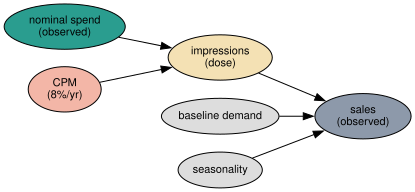

In [3]:
g = gr.Digraph(graph_attr={"rankdir": "LR"})
g.attr("node", fontname="Helvetica", fontsize="11")

g.node("spend", "nominal spend\n(observed)", style="filled", fillcolor="#2A9D8F")
g.node(
    "cpm",
    f"CPM\n({ANNUAL_CPM_INFLATION:.0%}/yr)",
    style="filled",
    fillcolor="#E76F5180",
)
g.node("impressions", "impressions\n(dose)", style="filled", fillcolor="#E9C46A80")
g.node("baseline", "baseline demand", style="filled", fillcolor="#dddddd")
g.node("season", "seasonality", style="filled", fillcolor="#dddddd")
g.node("y", "sales\n(observed)", style="filled", fillcolor="#1D355780")

with g.subgraph() as inputs:
    inputs.attr(rank="same")
    inputs.node("spend")
    inputs.node("cpm")

g.edge("spend", "impressions")
g.edge("cpm", "impressions")
g.edge("impressions", "y")
g.edge("baseline", "y")
g.edge("season", "y")
g

The next cell generates this example. Nominal spend and CPM determine impressions, while impressions, baseline demand, seasonality, and noise determine sales. This gives us both the data an analyst would normally have and reference variables that let us evaluate the fitted models.


In [4]:
def geometric_adstock_np(x: np.ndarray, alpha: float, l_max: int = 8) -> np.ndarray:
    weights = alpha ** np.arange(l_max)
    return np.convolve(x, weights, mode="full")[: len(x)]


def logistic_saturation_np(x: np.ndarray, lam: float) -> np.ndarray:
    return (1.0 - np.exp(-lam * x)) / (1.0 + np.exp(-lam * x))


n_weeks = 156
dates = pd.date_range("2023-01-02", periods=n_weeks, freq="W-MON")
years_elapsed = np.arange(n_weeks) / WEEKS_PER_YEAR

flight = 0.45 + 0.55 * ((np.arange(n_weeks) % 10) < 6).astype(float)
cpm_factor = (1.0 + ANNUAL_CPM_INFLATION) ** years_elapsed
spend_factor = (1.0 + ANNUAL_SPEND_GROWTH) ** years_elapsed

cpm = 10.0 * cpm_factor
spend = 5_000.0 * spend_factor * flight * (1.0 + 0.05 * rng.normal(size=n_weeks))
spend = np.clip(spend, 1.0, None)
impressions = spend * 1_000.0 / cpm

imp_scaled = impressions / impressions.max()
adstocked = geometric_adstock_np(imp_scaled, alpha=0.4, l_max=8)
media_true = 1_200.0 * logistic_saturation_np(adstocked, lam=2.5)

intercept_true = 2_000.0
season = 80.0 * np.sin(2.0 * np.pi * dates.dayofyear.to_numpy() / 365.25)
y = intercept_true + media_true + season + rng.normal(0.0, 40.0, size=n_weeks)

df = pd.DataFrame(
    {
        "date": dates,
        CHANNEL: spend,
        "impressions": impressions,
        "cpm": cpm,
        "y": y,
        "media_true": media_true,
    }
)

**Caption:** Nominal paid-social spend and impressions indexed to week 1 (= 100). Spend increases with budget growth, while impressions decrease because CPM increases faster than spend.


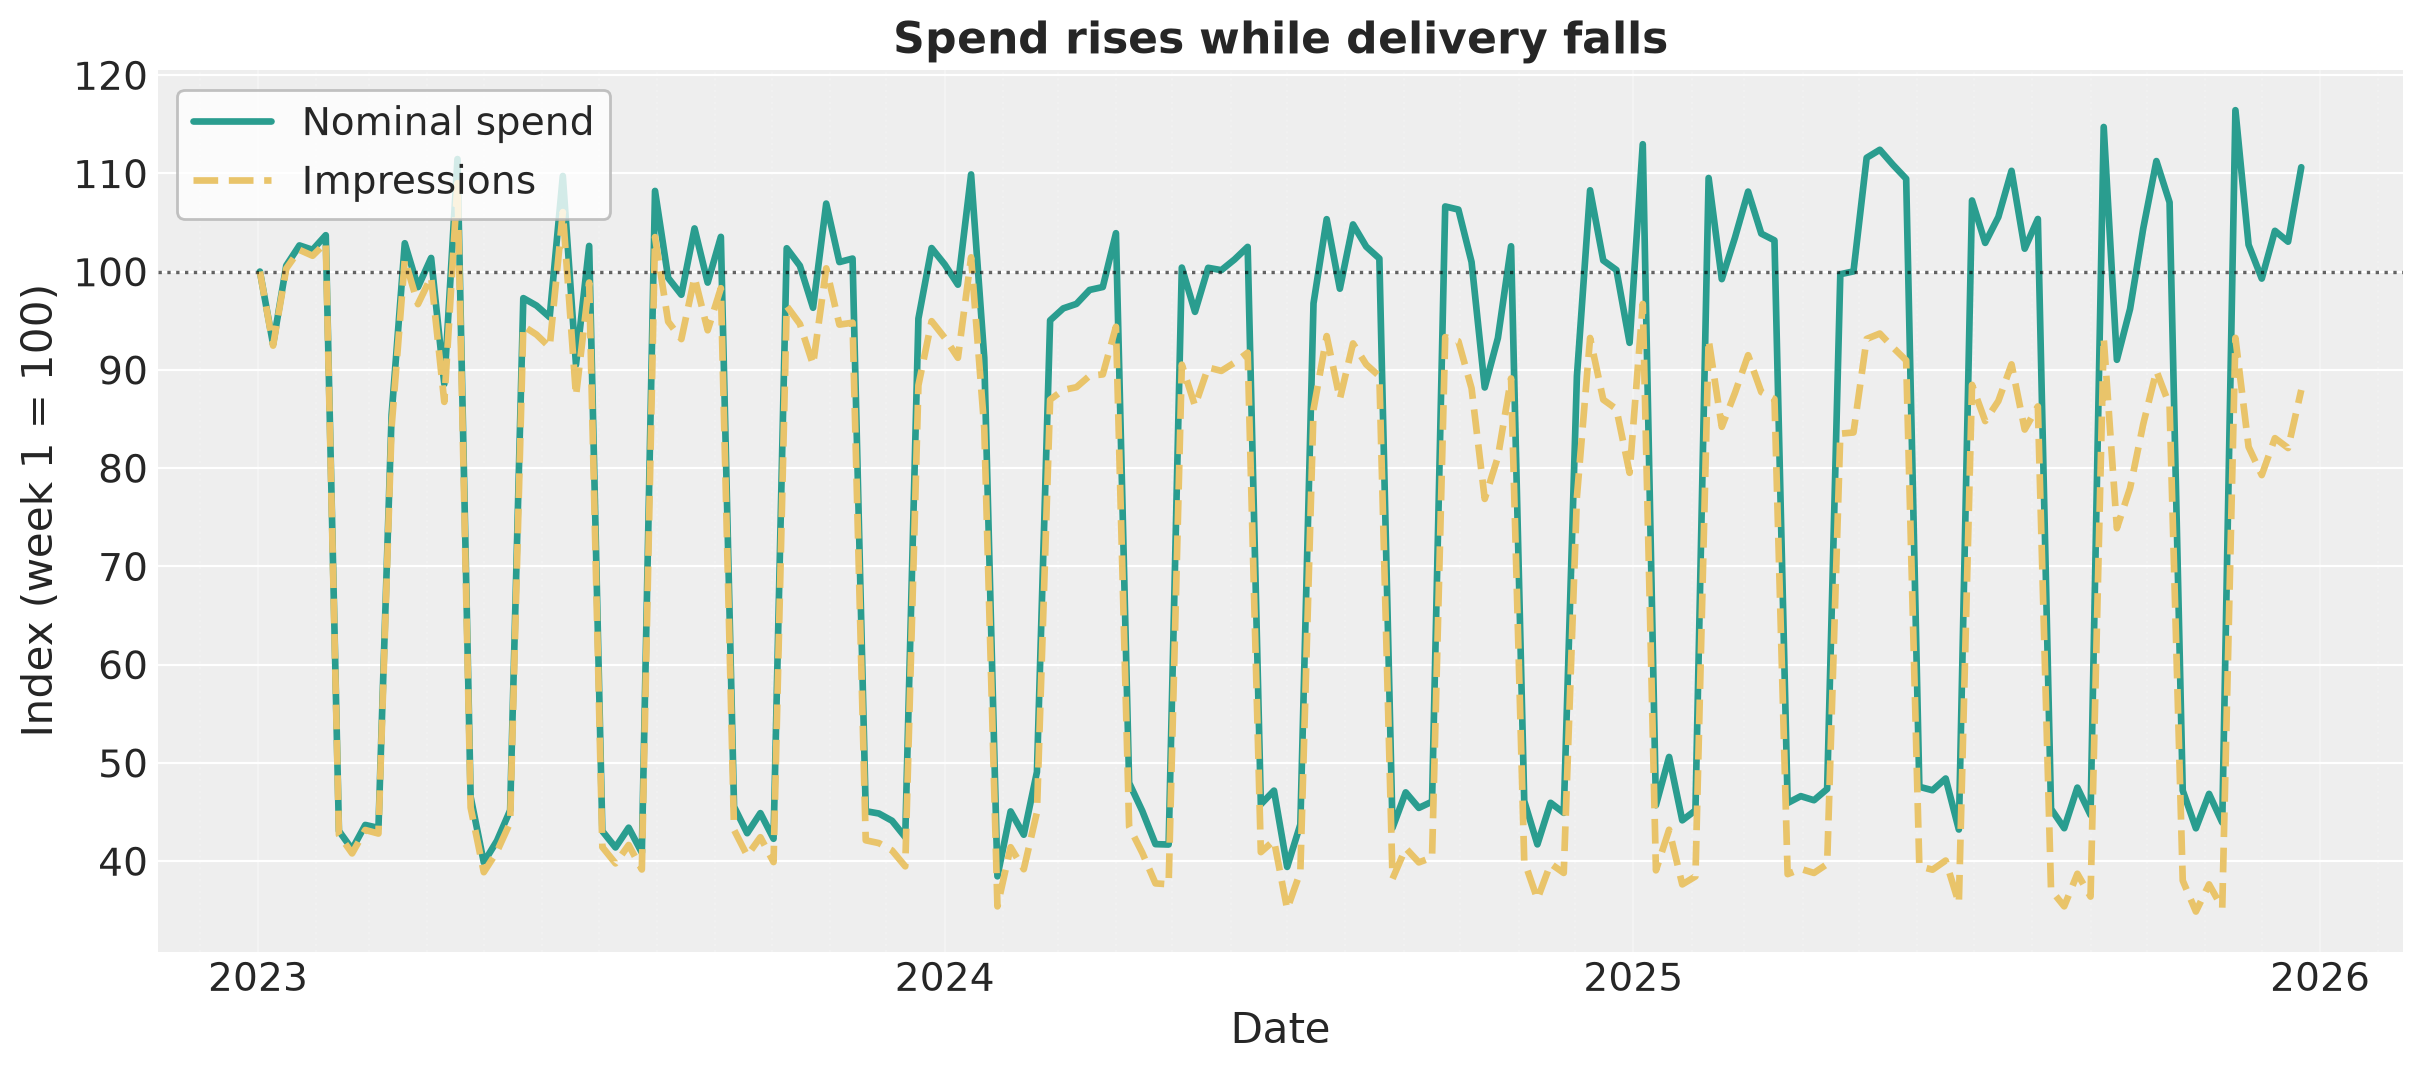

In [5]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT * 0.75))
spend_index = 100.0 * df[CHANNEL] / df[CHANNEL].iloc[0]
imp_index = 100.0 * df["impressions"] / df["impressions"].iloc[0]
ax.plot(
    df["date"], spend_index, color=COLOR_SPEND, linewidth=2.4, label="Nominal spend"
)
ax.plot(
    df["date"],
    imp_index,
    color=COLOR_IMPRESSIONS,
    linewidth=2.4,
    linestyle="--",
    label="Impressions",
)
ax.axhline(100.0, color="black", linestyle=":", linewidth=1.2, alpha=0.6)
ax.set_ylabel("Index (week 1 = 100)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", **LEGEND_KW)
ax.set_title("Spend rises while delivery falls", fontsize=16, fontweight="bold")
style_date_axis(ax)
plt.show()

**Caption:** Weekly CPM ($), nominal paid-social spend ($), impressions, and sales over 156 weeks. CPM increases faster than spend, impressions decrease, and sales remain approximately stable apart from campaign flighting, seasonality, and noise.


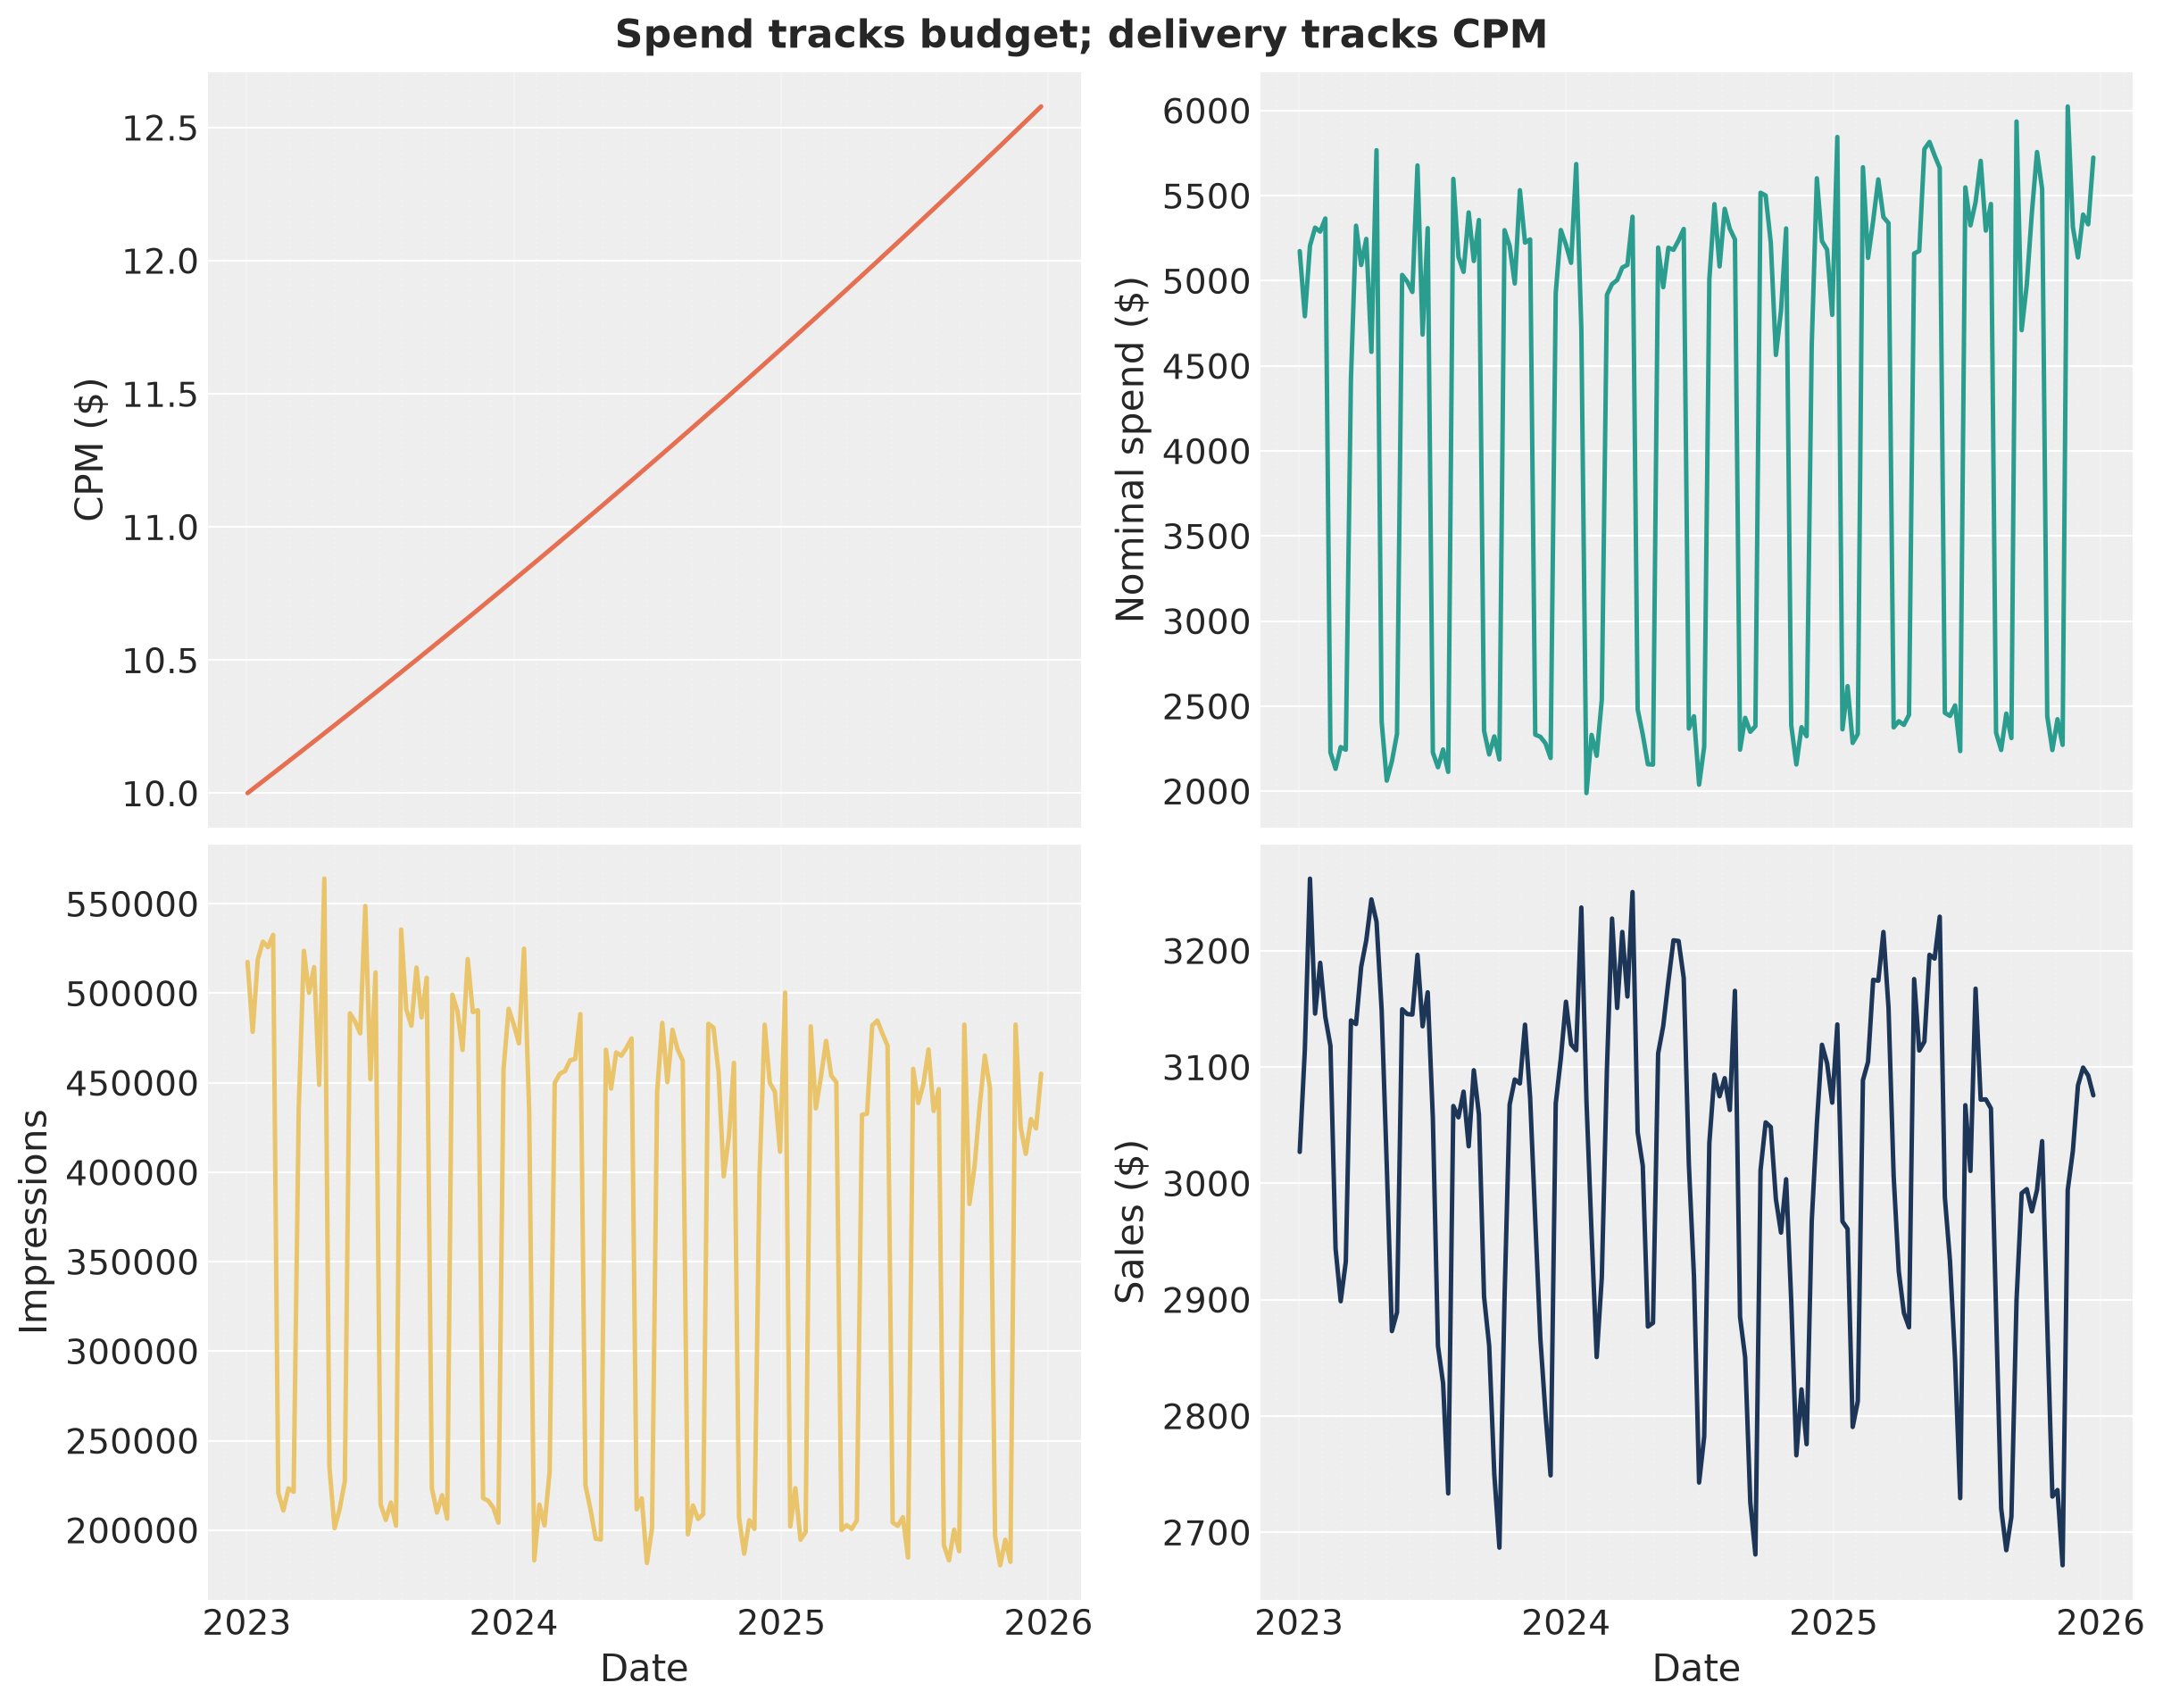

In [6]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(FIG_WIDTH, FIG_HEIGHT * 1.35),
    sharex=True,
)

series = [
    (axes[0, 0], "cpm", "CPM ($)", COLOR_CPM),
    (axes[0, 1], CHANNEL, "Nominal spend ($)", COLOR_SPEND),
    (axes[1, 0], "impressions", "Impressions", COLOR_IMPRESSIONS),
    (axes[1, 1], "y", "Sales ($)", COLOR_Y),
]
for ax, col, ylabel, color in series:
    ax.plot(df["date"], df[col], color=color, linewidth=1.8)
    ax.set_ylabel(ylabel)
    style_date_axis(ax)

axes[1, 0].set_xlabel("Date")
axes[1, 1].set_xlabel("Date")
fig.suptitle("Spend tracks budget; delivery tracks CPM", fontsize=16, fontweight="bold")
plt.show()

We now fit a baseline MMM using nominal spend. This is a useful comparison because it is a common starting point when delivery data or a cost index has not been prepared. The model specification is otherwise the same as in the adjusted-spend fit.


## Fit 1: using nominal spend

Both fits use geometric adstock, which represents the carryover of earlier advertising, and logistic saturation, which represents diminishing returns as media delivery increases. They also include yearly seasonality and a {class}`~pymc_marketing.mmm.additive_effect.LinearTrendEffect` with a handful of changepoints via {meth}`~pymc_marketing.mmm.mmm.MMM.add_mu_effect`. Only the media input $X$ changes.

The trend component represents the part of sales the model does not assign to media, seasonality, or other included effects. It is a model-implied contribution, not a separately observed series of baseline sales.

We do **not** set `time_varying_intercept=True`. A Hilbert-space Gaussian process (HSGP) intercept is slower and provides an even more flexible way to absorb gradual unit drift than the `LinearTrend` used here.

```{warning}
If your production MMM uses `time_varying_intercept=True`, CPM drift can still be absorbed by the baseline. Adjusting the media input is preprocessing; a flexible baseline is not a substitute for using stable media units.
```


In [7]:
def fit_mmm(X: pd.DataFrame, y: pd.Series) -> MMM:
    mmm = MMM(
        date_column="date",
        channel_columns=[CHANNEL],
        target_column="y",
        adstock=GeometricAdstock(l_max=8),
        saturation=LogisticSaturation(),
        yearly_seasonality=2,
    )
    mmm.add_mu_effect(
        LinearTrendEffect(
            trend=LinearTrend(n_changepoints=3),
            prefix="trend",
        )
    )
    mmm.fit(X, y, **FIT_KWARGS)
    return mmm


def plot_posterior_band(
    ax, dates, da, color, label, alpha=0.3, linewidth=2.5, line_alpha=1.0
):
    hdi = az.hdi(da, prob=0.94)
    ax.fill_between(
        dates,
        np.asarray(hdi.sel(ci_bound="lower")).squeeze(),
        np.asarray(hdi.sel(ci_bound="upper")).squeeze(),
        color=color,
        alpha=alpha,
        zorder=1,
    )
    ax.plot(
        dates,
        da.mean(("chain", "draw")).to_numpy().squeeze(),
        color=color,
        linewidth=linewidth,
        alpha=line_alpha,
        label=label,
        zorder=3,
    )


def plot_media_vs_trend(ds, dates, media_true, ylim_media, ylim_trend, title):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 1.35),
        sharex=True,
    )
    plot_posterior_band(axes[0], dates, ds[CHANNEL], COLOR_MEDIA, "Fitted media")
    axes[0].plot(
        dates,
        media_true,
        color="black",
        linestyle="--",
        linewidth=2.0,
        label="True media",
        zorder=5,
    )
    axes[0].set_ylabel("Media contribution ($)")
    axes[0].legend(loc="upper left", **LEGEND_KW)
    axes[0].set_ylim(ylim_media)

    plot_posterior_band(axes[1], dates, ds["trend_effect"], COLOR_TREND, "Fitted trend")
    axes[1].axhline(
        0.0,
        color="black",
        linestyle="--",
        linewidth=2.0,
        label="True trend (0)",
        zorder=5,
    )
    axes[1].set_ylabel("Trend contribution ($)")
    axes[1].set_xlabel("Date")
    axes[1].legend(loc="upper left", **LEGEND_KW)
    axes[1].set_ylim(ylim_trend)
    style_date_axis(axes[1])

    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.show()
    return fig, axes


def mean_by_year(da, dates: pd.Series) -> pd.Series:
    s = da.mean(("chain", "draw")).to_series()
    s.index = pd.to_datetime(dates.to_numpy())
    return s.groupby(s.index.year).mean()


def half_window_slope(x) -> float:
    values = np.asarray(x).squeeze()
    half = len(values) // 2
    return float(values[-half:].mean() - values[:half].mean())

In [8]:
X_nominal = df[["date", CHANNEL]].copy()
y = df["y"]

mmm_nominal = fit_mmm(X_nominal, y)
ds_nominal = mmm_nominal.compute_counterfactual_contributions_dataset()

NUTS[nutpie]: [delta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, y_sigma]


Output()

Output()

Contributions are on the original scale of $y$, via {meth}`~pymc_marketing.mmm.mmm.MMM.compute_counterfactual_contributions_dataset`. The black dashed line is the planted media contribution (gentle decline with delivery; flighting visible week to week), not a model output.


In [9]:
hdi_media = az.hdi(ds_nominal[CHANNEL], prob=0.94)
hdi_trend = az.hdi(ds_nominal["trend_effect"], prob=0.94)
ylim_media = (
    0.0,
    max(
        float(np.asarray(hdi_media.sel(ci_bound="upper")).max()),
        1.25 * float(df["media_true"].max()),
    ),
)
pad_media = 0.08 * ylim_media[1]
ylim_media = (0.0, ylim_media[1] + pad_media)

ylim_trend = (
    min(float(np.asarray(hdi_trend.sel(ci_bound="lower")).min()), 0.0),
    max(float(np.asarray(hdi_trend.sel(ci_bound="upper")).max()), 0.0),
)
pad_trend = 0.08 * (ylim_trend[1] - ylim_trend[0])
ylim_trend = (ylim_trend[0] - pad_trend, ylim_trend[1] + pad_trend)

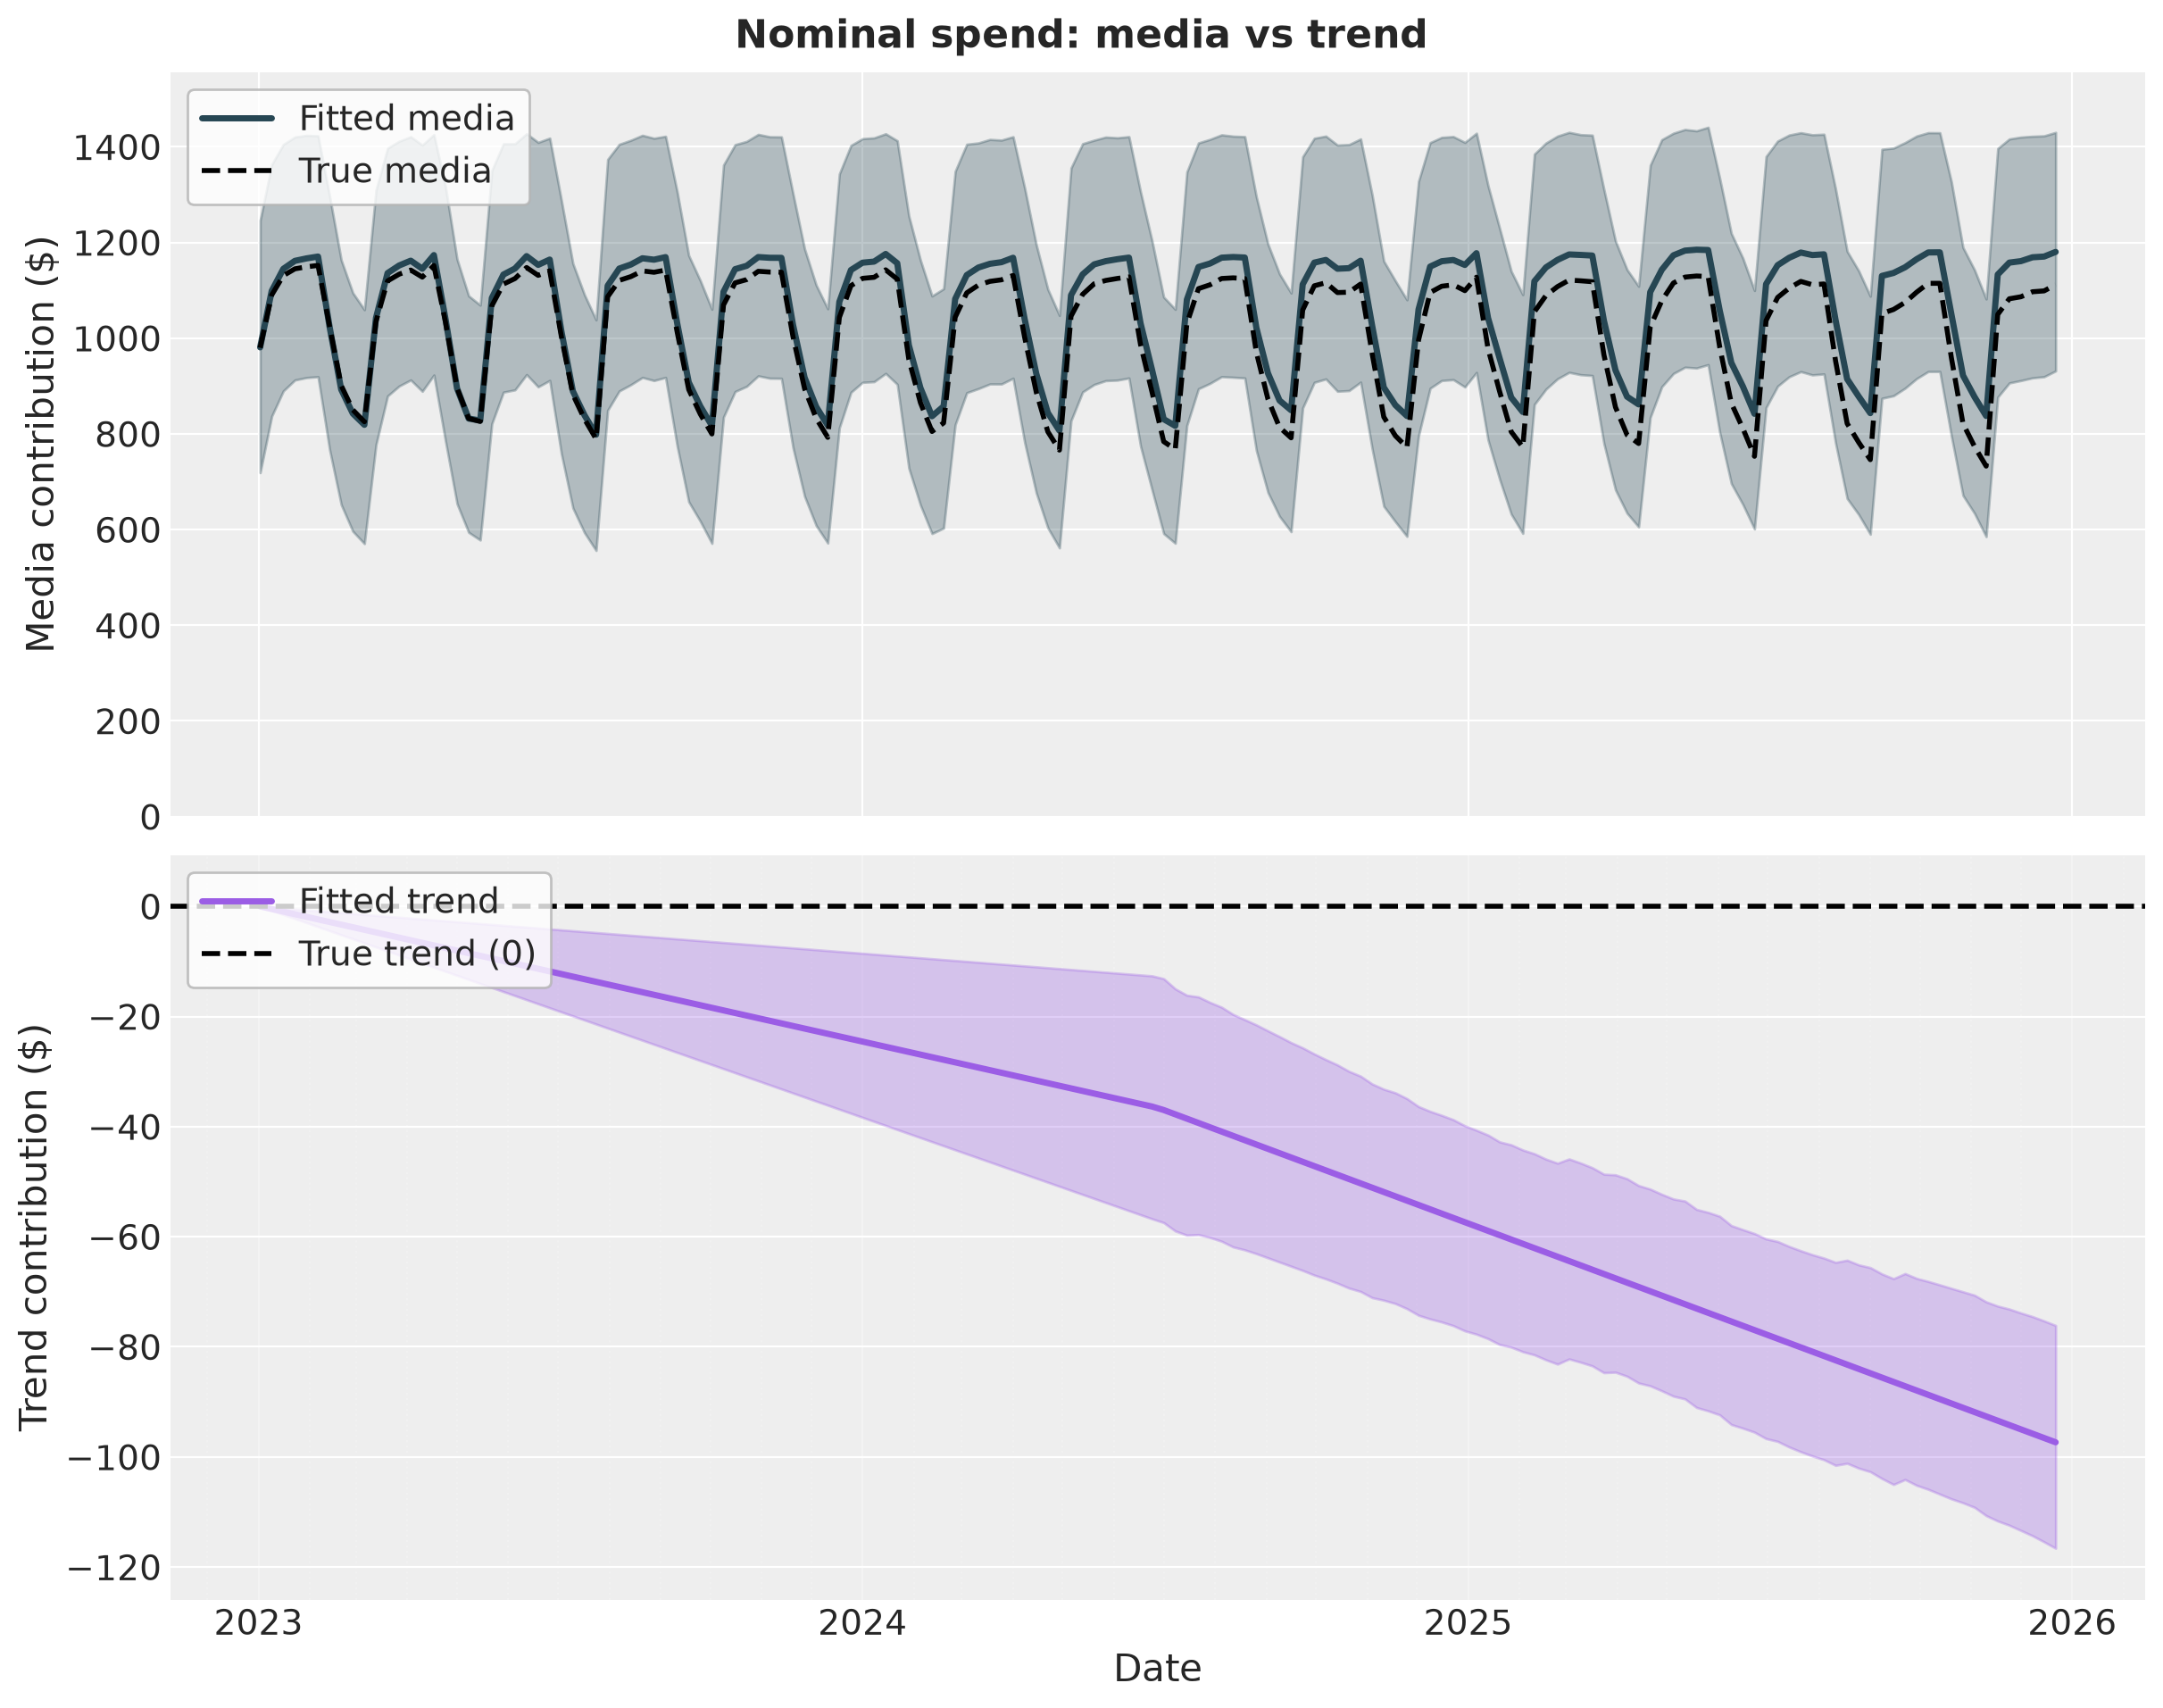

(<Figure size 1200x945 with 2 Axes>,
 array([<Axes: ylabel='Media contribution ($)'>,
        <Axes: xlabel='Date', ylabel='Trend contribution ($)'>],
       dtype=object))

In [10]:
plot_media_vs_trend(
    ds_nominal,
    df["date"],
    df["media_true"],
    ylim_media,
    ylim_trend,
    title="Nominal spend: media vs trend",
)

**Caption:** Posterior mean and 94% highest-density interval (HDI) for paid-social media contribution (top) and model-implied `LinearTrend` contribution (bottom) when the MMM is fit on nominal spend. Black dashed lines show the simulated reference media contribution and the reference trend of zero. The media panel starts at zero.


```{important}
**Interpret the decomposition carefully.** Later weeks have higher nominal spend but fewer impressions. A time-invariant saturation curve maps the increasing dollars to an increasing fitted media contribution, even though the reference media contribution falls with delivery. Because total sales remain roughly flat, the model-implied trend contribution falls to offset the media contribution.

The declining trend is therefore not observed declining baseline sales. It is the model's decomposition of stable sales when the media input has not been adjusted for inflation. A good in-sample fit does not establish that the model recovered the correct mechanism; compare the trajectories, not only their averages.
```


## Deflate spend before fitting

Adstock and saturation are functions of the media input. If that input is nominal spend, the model treats "$100 of ads in 2023" as equivalent to "$100 of ads today." When media prices rise, those two amounts can buy different amounts of delivery.

We convert historical spend to **today's dollars**, where today means the last date in the sample:

$$
I_t = \frac{p_t}{p_{\text{today}}}, \qquad x^{\text{today}}_t = \frac{x^{\text{nom}}_t}{I_t}.
$$

Here $I_t$ is a smooth media-cost index. If it tracks the cost of an impression, adjusted spend should be proportional to impressions and is a more stable input for the MMM.

```{important}
Calling {meth}`~pymc_marketing.mmm.mmm.MMM.set_cost_per_unit` on an already-fitted **spend** model only changes the denominator used for ROAS (return on ad spend). It does not rewrite the media input, so it cannot fix attribution. Deflate spend, or fit delivery units, *before* `fit`.
```

```{warning}
Do not use time-varying *media* (`time_varying_media=True`) to absorb inflation. That multiplier is for genuine changes in media efficiency. A gradual change in the units of the predictor is a preprocessing issue.
```


## Fit 2: using today's dollars

The adjustment itself is three lines. The example uses an 8% annual cost increase as though it came from an external benchmark. In practice, the index is an estimate, so we will test how different assumptions affect the attribution.


In [11]:
years_elapsed = np.arange(len(X_nominal)) / WEEKS_PER_YEAR
index = (1.0 + ANNUAL_CPM_INFLATION) ** (years_elapsed - years_elapsed[-1])
X_today = X_nominal.copy()
X_today[CHANNEL] = X_nominal[CHANNEL] / index

X_today.head()

,date,paid_social
0,2023-01-02,6507.978538
1,2023-01-09,6017.246234
2,2023-01-16,6527.710303
3,2023-01-23,6651.469742
4,2023-01-30,6612.604152


```{tip}
A smooth annual or quarterly media-cost index is usually enough. Noisy weekly CPM can put auction volatility into the predictor instead of removing the gradual price trend.
```

As a simple validation, adjusted spend should follow impressions up to a constant scale when the index tracks the cost of an impression. The next figure checks that relationship in the simulated data.


**Caption:** Nominal paid-social spend ($/week), spend converted to today's dollars using $I_t = p_t / p_{\text{today}}$, and impressions rescaled to the mean of adjusted spend. Adjusted spend follows the delivery series.


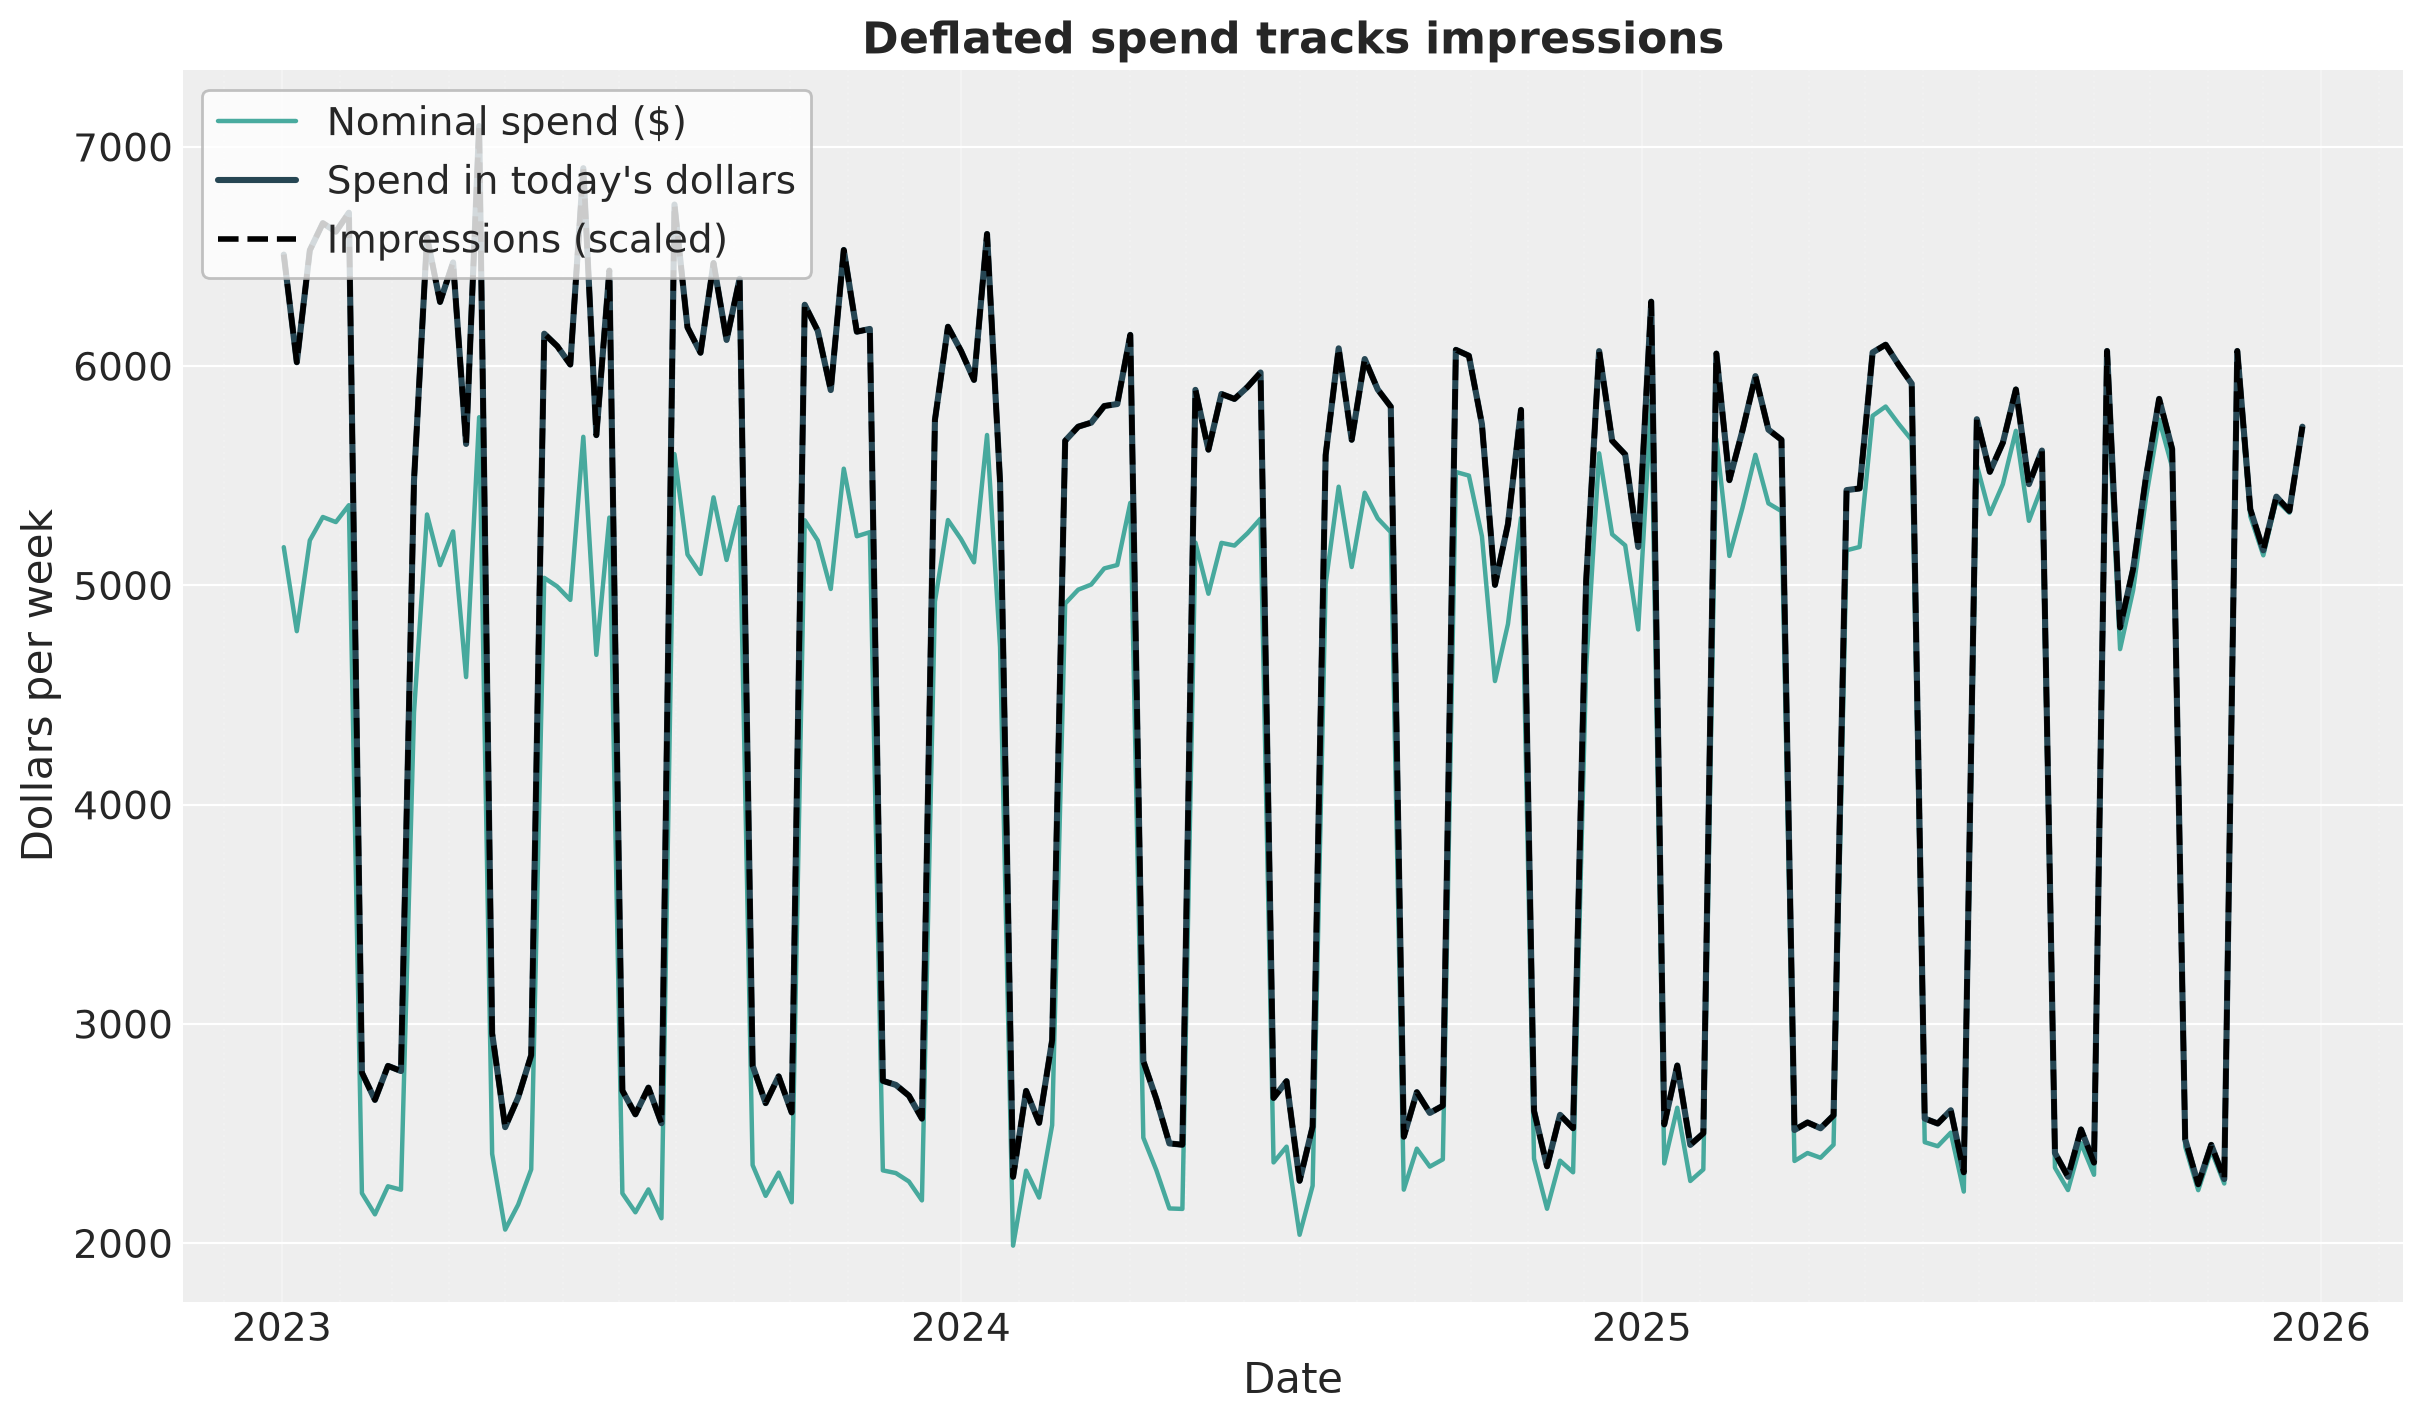

In [12]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
scale = X_today[CHANNEL].mean() / df["impressions"].mean()
ax.plot(
    df["date"],
    X_nominal[CHANNEL],
    color=COLOR_SPEND,
    linewidth=1.6,
    alpha=0.85,
    label="Nominal spend ($)",
)
ax.plot(
    df["date"],
    X_today[CHANNEL],
    color=COLOR_MEDIA,
    linewidth=2.2,
    label="Spend in today's dollars",
)
ax.plot(
    df["date"],
    df["impressions"] * scale,
    color="black",
    linestyle="--",
    linewidth=2.0,
    label="Impressions (scaled)",
    zorder=5,
)
ax.set_xlabel("Date")
ax.set_ylabel("Dollars per week")
ax.legend(loc="upper left", **LEGEND_KW)
ax.set_title("Deflated spend tracks impressions", fontsize=16, fontweight="bold")
style_date_axis(ax)
plt.show()

In [13]:
mmm_today = fit_mmm(X_today, y)
ds_today = mmm_today.compute_counterfactual_contributions_dataset()

NUTS[nutpie]: [delta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, y_sigma]


Output()

Output()

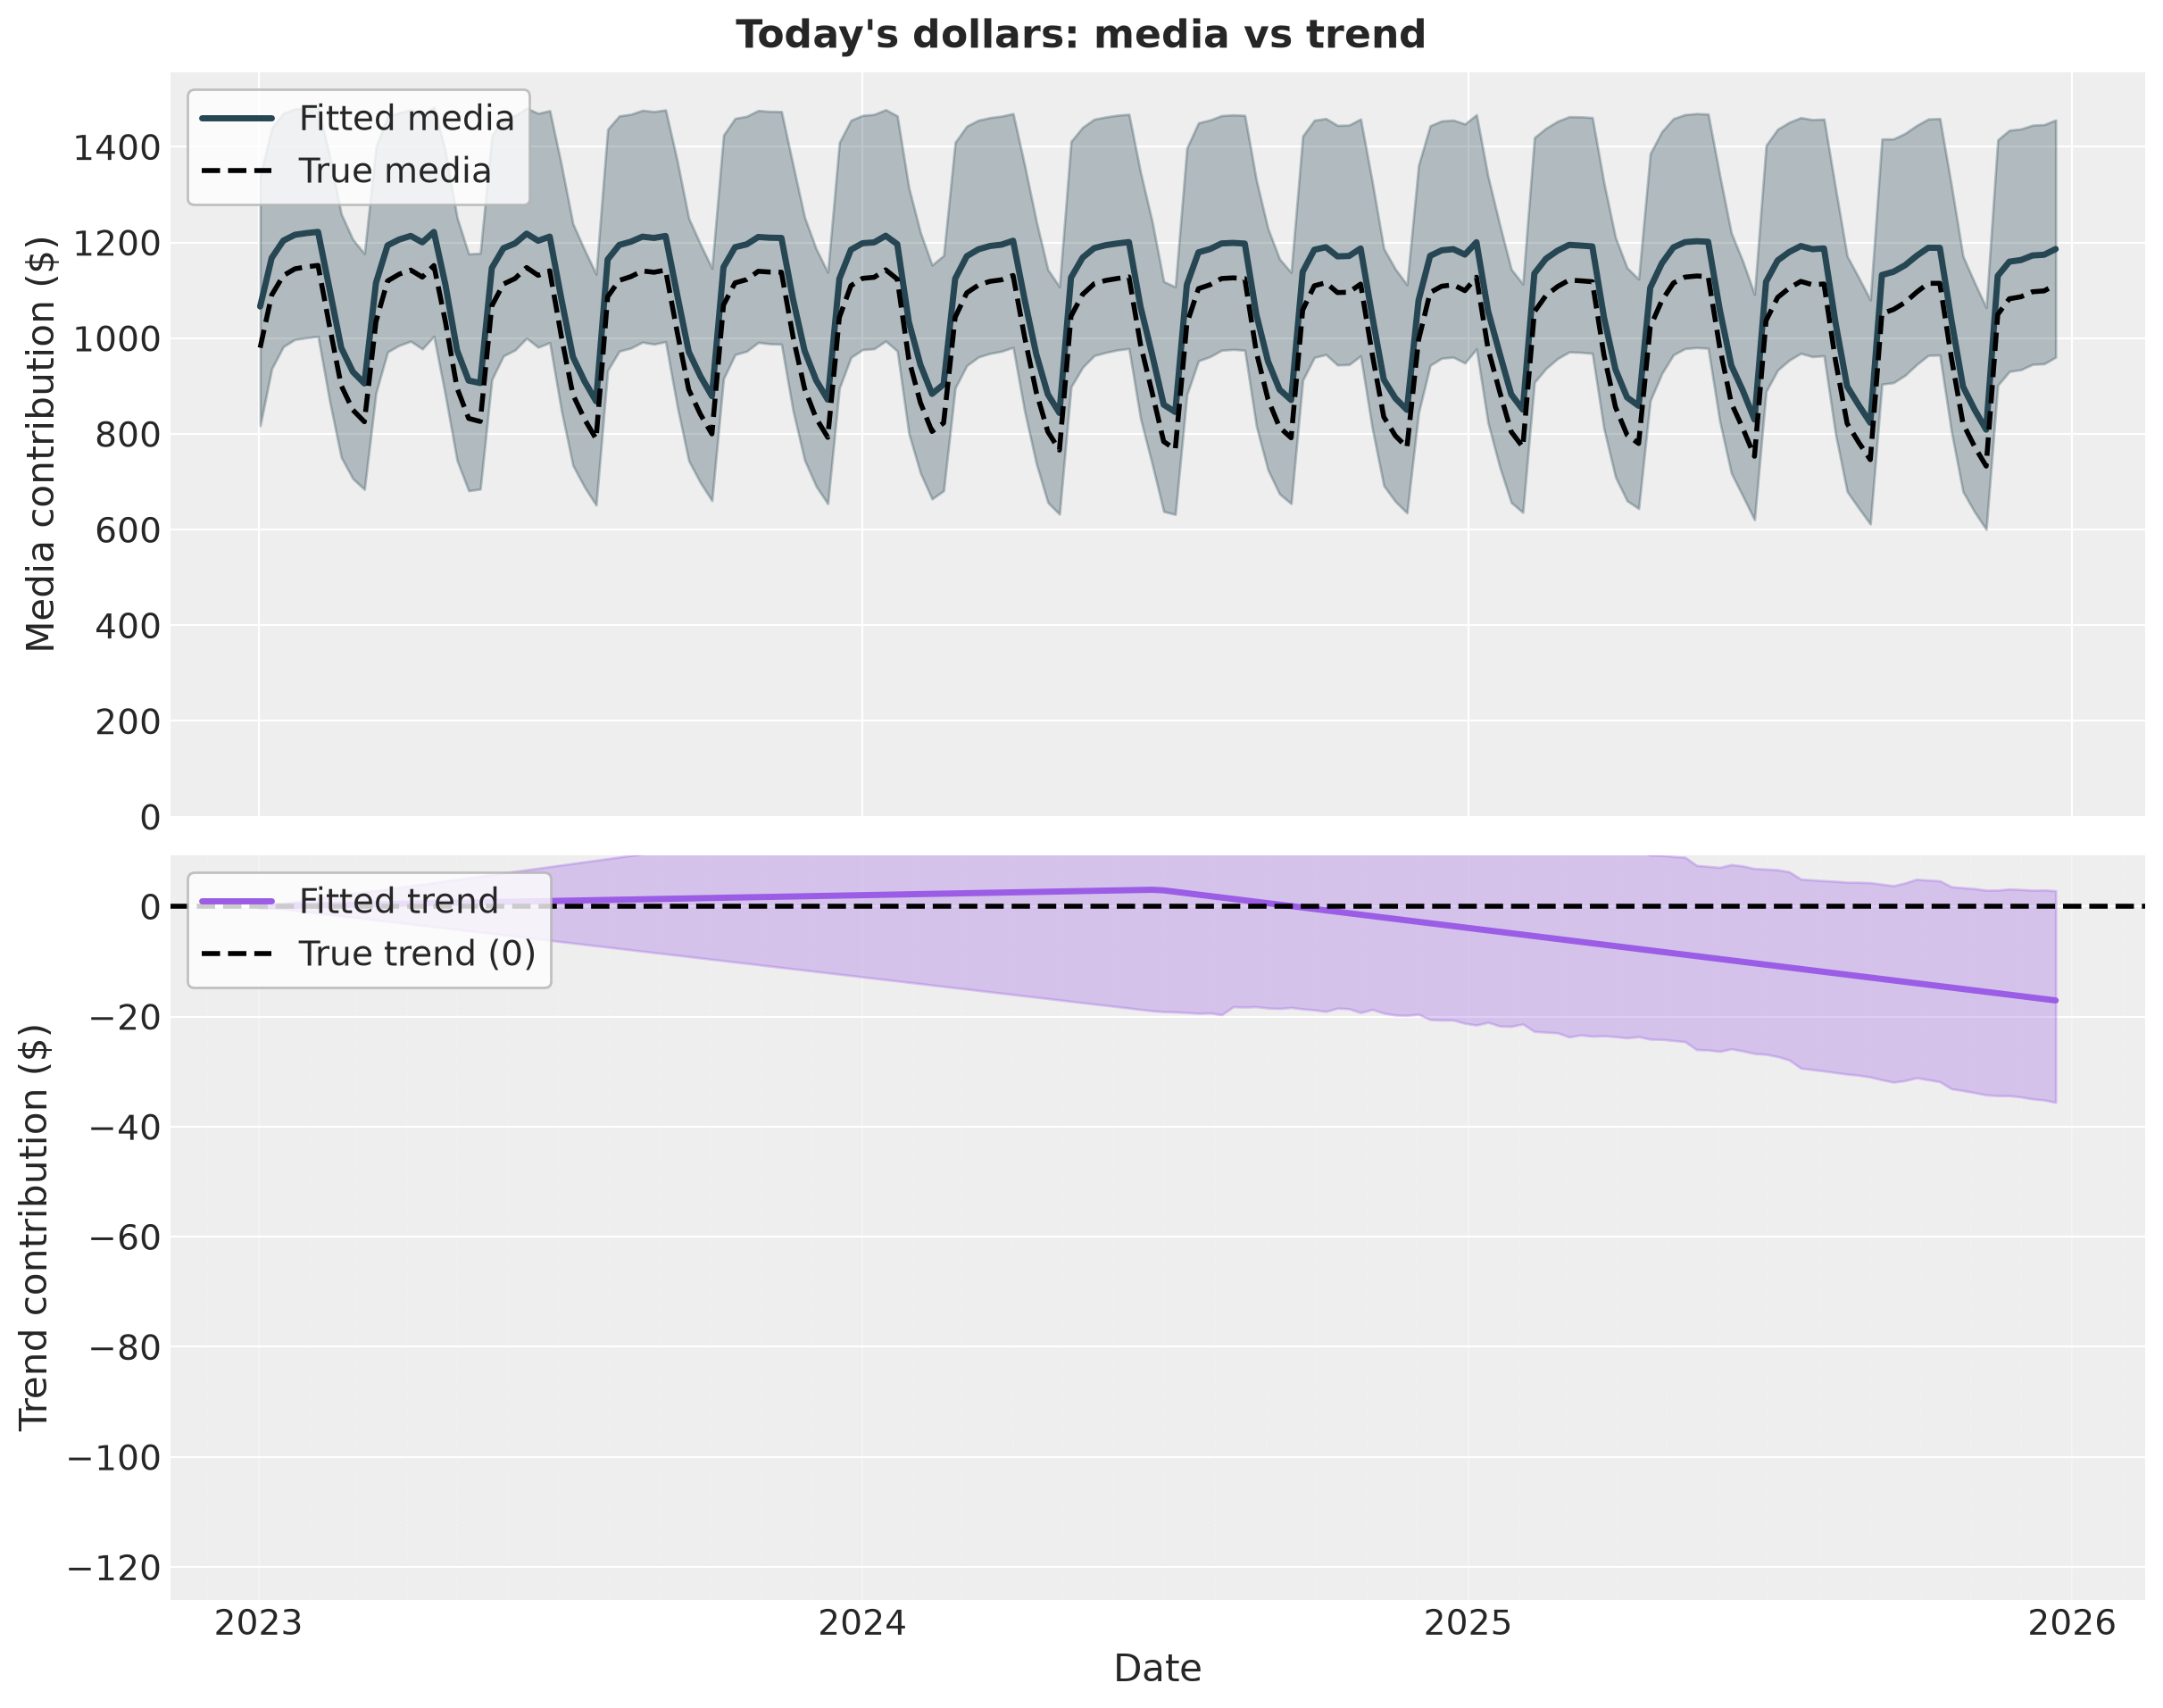

(<Figure size 1200x945 with 2 Axes>,
 array([<Axes: ylabel='Media contribution ($)'>,
        <Axes: xlabel='Date', ylabel='Trend contribution ($)'>],
       dtype=object))

In [14]:
plot_media_vs_trend(
    ds_today,
    df["date"],
    df["media_true"],
    ylim_media,
    ylim_trend,
    title="Today's dollars: media vs trend",
)

**Caption:** Posterior mean and 94% HDI for media (top) and model-implied `LinearTrend` contribution (bottom) after converting spend to the last sample date. Axes match the nominal-spend contribution figure. Black dashed lines show the simulated reference media contribution and reference trend of zero.


After adjustment, fitted media follows the weekly shape of the reference series, including campaign flighting and the gradual decline in delivery. The model-implied trend is now a smaller residual contribution rather than a strong declining pattern.

The level is only approximately recovered. The important result is that changing the units of $X$ reduces the systematic attribution error; it does not make the inflation index or the model an oracle.


## Compare the two fits

The two models use the same adstock, saturation, seasonality, trend, and sales data. Only the units of the media input change. The media contribution is shown in the preceding plots; this comparison focuses on the model-implied trend, where the effect of the media units is largest.


**Caption:** Posterior mean and 94% HDI for model-implied trend contribution under nominal spend and today's dollars. The black dashed line shows the simulated reference trend of zero.


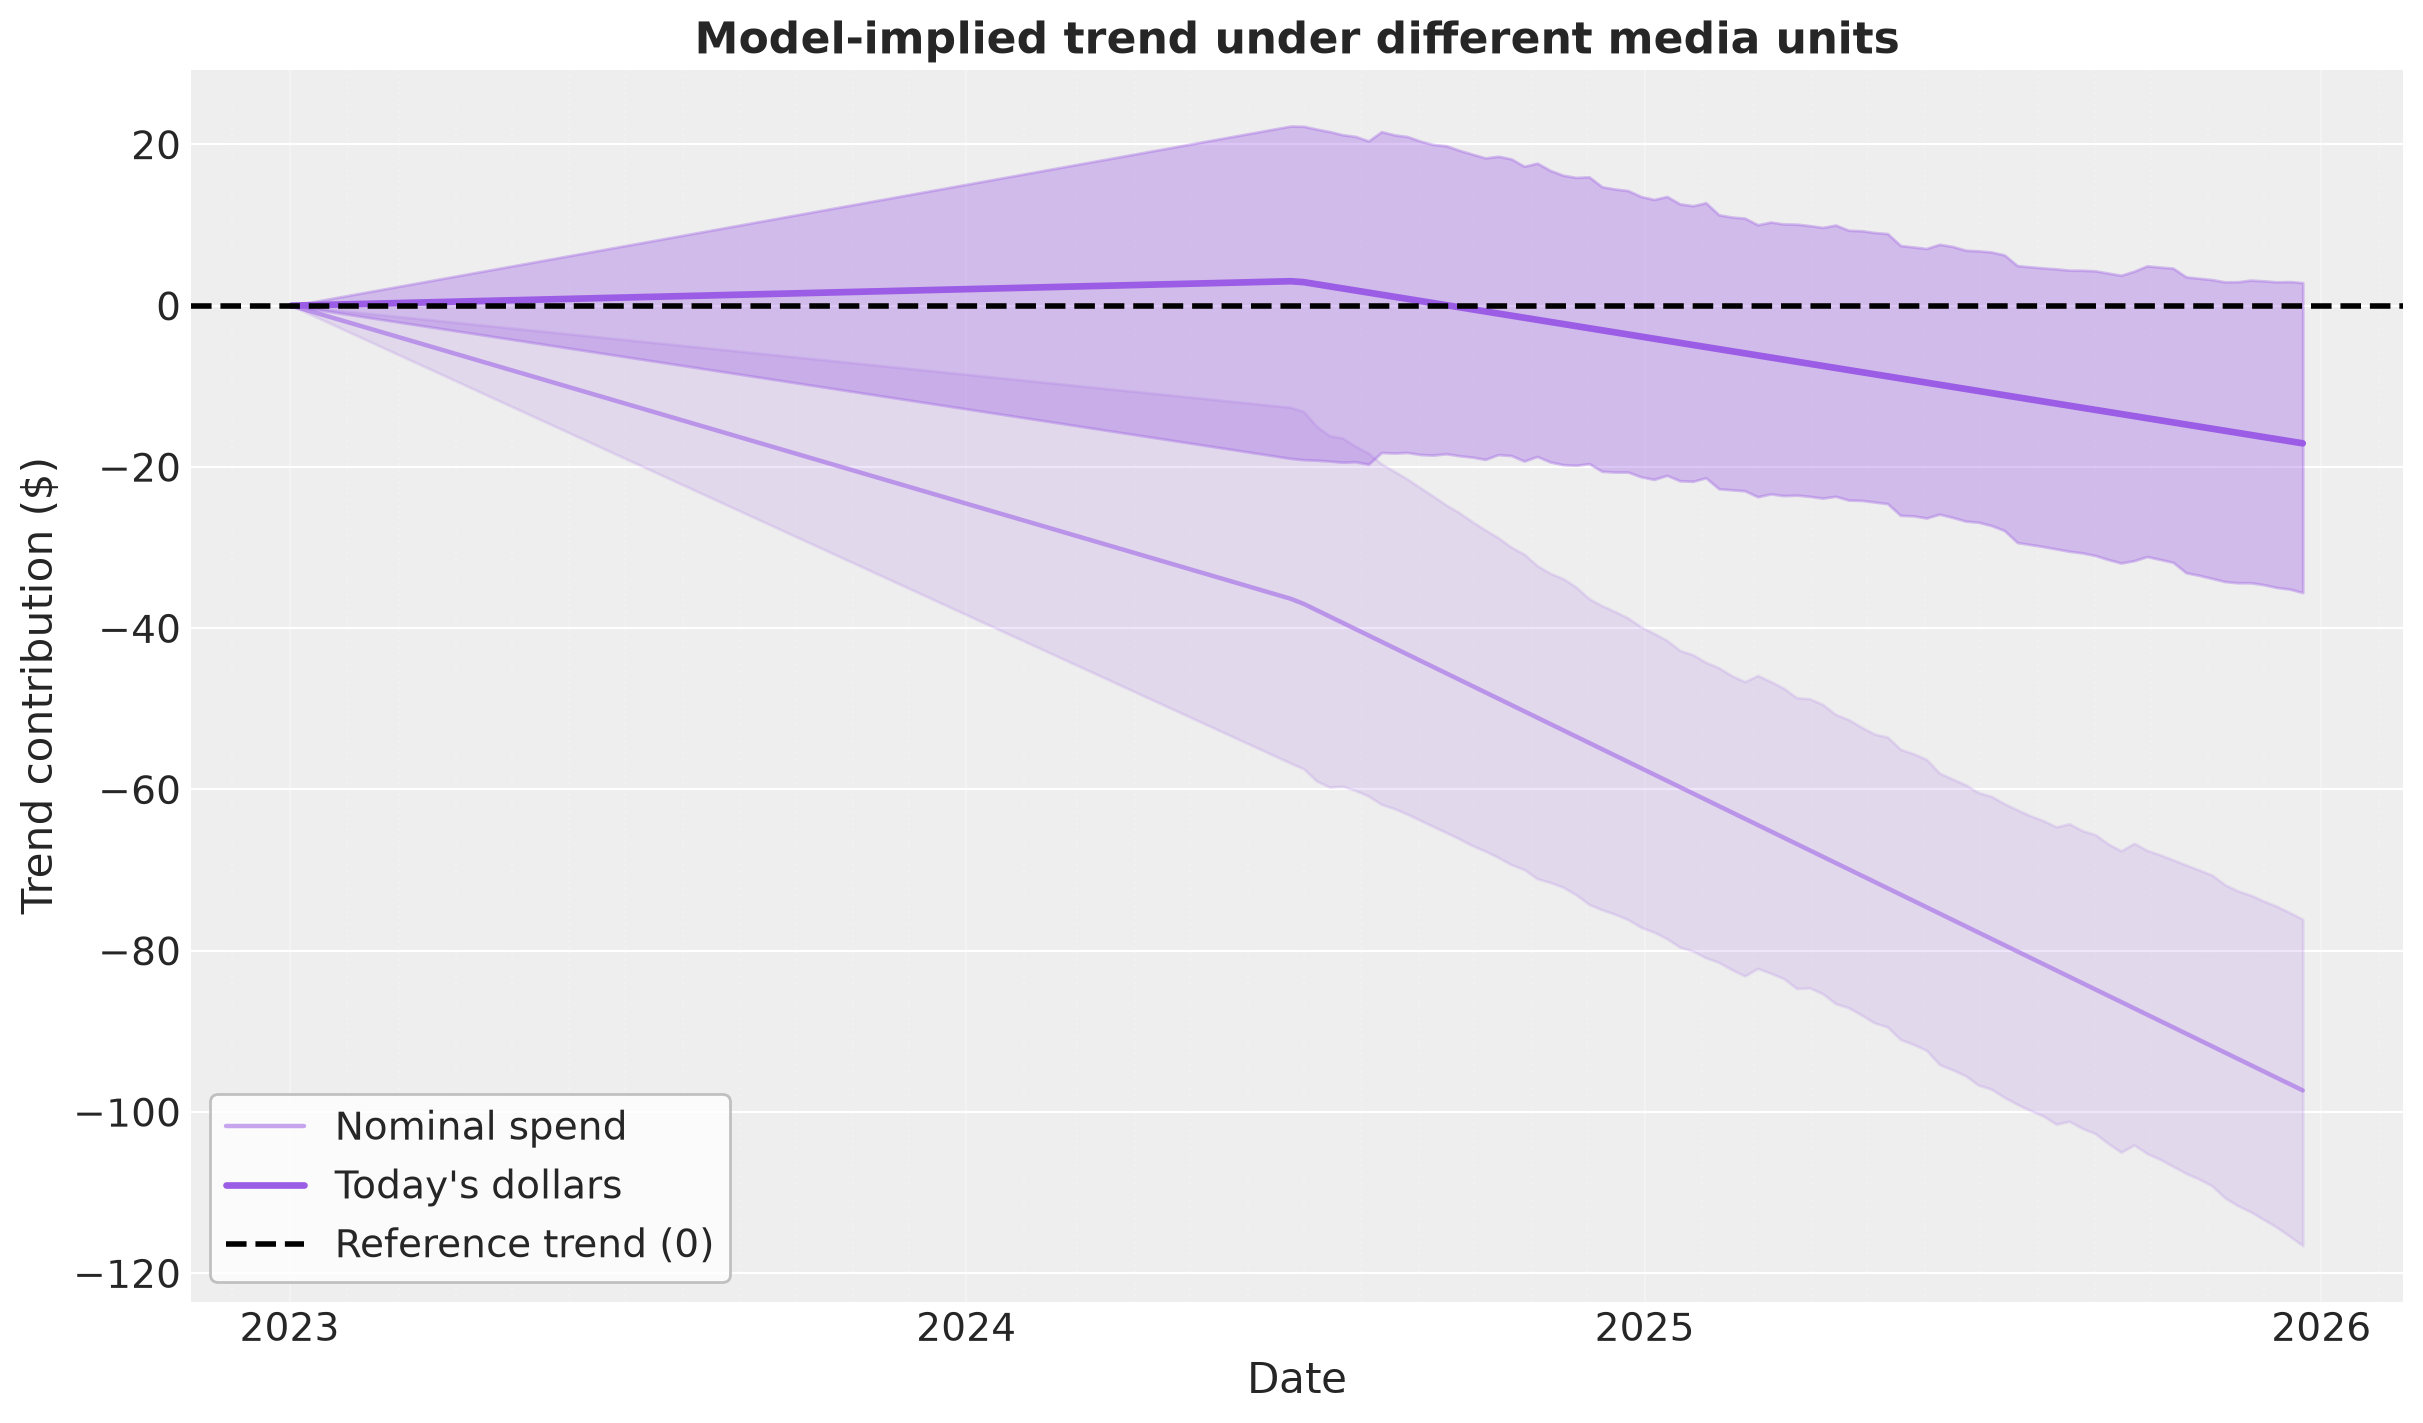

In [ ]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

variants = [
    (ds_nominal, "Nominal spend", 0.15, 1.6, 0.55),
    (ds_today, "Today's dollars", 0.35, 2.4, 1.0),
]
for ds, label, alpha, lw, line_alpha in variants:
    plot_posterior_band(
        ax,
        df["date"],
        ds["trend_effect"],
        COLOR_TREND,
        label,
        alpha=alpha,
        linewidth=lw,
        line_alpha=line_alpha,
    )

ax.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=2.0,
    label="Reference trend (0)",
    zorder=5,
)
ax.set_ylabel("Trend contribution ($)")
ax.set_xlabel("Date")
ax.legend(loc="lower left", **LEGEND_KW)
ax.set_title(
    "Model-implied trend under different media units", fontsize=16, fontweight="bold"
)
style_date_axis(ax)
plt.show()

In [16]:
years = df["date"].dt.year
comparison = pd.DataFrame(
    {
        "true_media": df.groupby(years)["media_true"].mean(),
        "nominal_media": mean_by_year(ds_nominal[CHANNEL], df["date"]),
        "nominal_trend": mean_by_year(ds_nominal["trend_effect"], df["date"]),
        "today_media": mean_by_year(ds_today[CHANNEL], df["date"]),
        "today_trend": mean_by_year(ds_today["trend_effect"], df["date"]),
    }
)
comparison.index.name = "year"
comparison.round(1)

,true_media,nominal_media,nominal_trend,today_media,today_trend
year,,,,,
2023,1028.4,1045.3,-12.0,1104.4,1.0
2024,1010.1,1055.1,-39.0,1086.7,1.0
2025,995.9,1068.7,-77.7,1072.8,-10.6


The table summarizes mean weekly contributions by year. With nominal spend, the model-implied media contribution increases while the reference media contribution decreases, and the model-implied trend becomes more negative to offset that difference. The average media contribution can still look plausible, so the trajectory is more informative than the average alone.

After adjustment, the media trajectory moves toward the reference delivery pattern and the trend contribution is smaller. This is preprocessing, not a hidden MMM switch: both models share the same specification and differ only in the units of $X$.


## Summary and practical guidance

For most MMMs, choose the input that best represents media exposure rather than only the monetary cost. Use the following guide when preparing your data.

| Situation | Recommended MMM input | Why |
| --- | --- | --- |
| Impressions or GRPs are available | Fit impressions or GRPs directly | In the example DAG, delivery is the mediator between spend and sales, so it is the most direct measure of exposure. Keep spend for cost and return-on-ad-spend reporting. |
| Spend and CPM or cost-per-GRP are available | Reconstruct delivery from spend and a smooth cost-per-unit series | This uses the delivery measure that the model needs while retaining the observed cost information for reporting. |
| Only spend is available | Deflate spend with a smooth external media-cost index before `fit` | The adjustment makes historical currency values more comparable when media prices have changed over time. Treat the index as an estimate. |
| The question is specifically about budget or cost dynamics | Model spend deliberately, with a clearly stated estimand | This is a different use case from estimating the contribution of media exposure and may require an explicit cost or delivery model. |

Within this example's DAG, do not automatically provide spend and impressions as two independent media channels. Spend is upstream of impressions, so including both requires a separate modelling argument about any direct effect of spend on sales.

**Summary.**

- Media inflation can make nominal spend rise while impressions or GRPs fall.
- A nominal-spend MMM may fit stable sales by increasing its media contribution and decreasing its model-implied trend. That declining trend is an inferred decomposition, not observed declining baseline sales.
- `set_cost_per_unit` changes the denominator used for return on ad spend after fitting. It does not correct a media input specified in the wrong units.
- When the cost index is uncertain, assess whether your attribution conclusions change across plausible assumptions.

**Next steps.** Long-horizon budget optimisation and scenario planning also need future cost-per-unit assumptions, because future dollars may buy less delivery. That workflow is outside the scope of this attribution example.

```{note}
For optimization, use a future cost-per-unit or a decision variable expressed in stable delivery units rather than assuming that last year's nominal dollars retain the same media value.
```

**Reflection.** For a channel in your own work, compare the trend in budget with the trend in CPM, cost-per-GRP, or another cost-per-unit measure. Which input would best represent exposure for paid-social auctions, television, or out-of-home media?


In [17]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing

Last updated: Fri, 04 Sep 2026

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.15.0

pymc_marketing: 1.1.0

arviz         : 1.2.0
graphviz      : 0.21
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 2.3.3
pymc_marketing: 1.1.0

Watermark: 2.6.0

